In [10]:
#Importando bibliotecas
import pandas as pd
import seaborn as sns
import numpy as np

In [11]:
df = pd.read_csv("../data/processed/olist_processado.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   customer_unique_id             113425 non-null  object 
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  object 
 11  customer_state                 113425 non-null  object 
 12  order_item_id                 

In [13]:
#filtro de status
df_status = df[df["order_status"] == "delivered"]

#pedidos por unico cliente
pedidos_por_cliente = df_status.groupby('customer_unique_id')['order_id'].nunique()

#clientes com recompra
clientes_recompra = (pedidos_por_cliente >= 2).sum()

#total de clientes
total_clientes = pedidos_por_cliente.count()

#taxa de recompra
taxa_recompra = clientes_recompra / total_clientes
print(f"Taxa de recompra: {taxa_recompra:.2%}")



Taxa de recompra: 3.00%


Distribuição do intervalo entre 1 e 2 compra

<Axes: xlabel='intervalo_dias', ylabel='Count'>

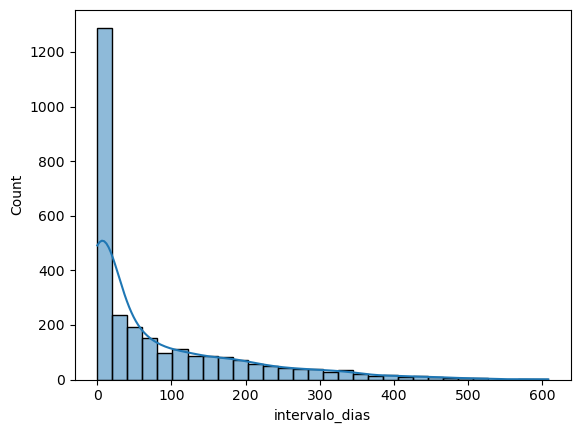

In [19]:
#Removendo pedidos duplicados
pedidos_unicos = df_status.drop_duplicates(subset=['customer_unique_id', 'order_id'])

#Ordernar por clientes
pedidos_ordenados = pedidos_unicos.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
pedidos_ordenados['order_purchase'] = pedidos_ordenados.groupby('customer_unique_id').cumcount()

#converter variavel order_purchase_timestamp para datetime
pedidos_ordenados['order_purchase_timestamp'] = pd.to_datetime(pedidos_ordenados['order_purchase_timestamp'])

#Pivotar
pivot = pedidos_ordenados[pedidos_ordenados['order_purchase'] <= 1].pivot(index='customer_unique_id', columns='order_purchase', values='order_purchase_timestamp')

#calcular intervalo de dias
pivot['intervalo_dias'] = (pivot[1] - pivot[0]).dt.days

#remover clientes que não realizaram mais de 1 compra
pivot = pivot.dropna(subset=['intervalo_dias'])

#visualizar distribuição
sns.histplot(pivot['intervalo_dias'], bins=30, kde=True)

Ticket médio por região

In [24]:
#Valor de cada pedido com região
pedido_valor = df_status[['order_id', 'customer_state', 'price', 'freight_value']].groupby(['order_id', 'customer_state'])[['price', 'freight_value']].sum().reset_index()

#ticket
pedido_valor['ticket'] = pedido_valor['price'] + pedido_valor['freight_value']

#média por região
ticket_medio_regiao = pedido_valor.groupby('customer_state')['ticket'].mean()

In [26]:
ticket_medio_regiao

customer_state
AC    244.691625
AL    237.210302
AM    190.244621
AP    240.922537
BA    181.553381
CE    208.316474
DF    166.405457
ES    159.227033
GO    170.777900
MA    206.141632
MG    160.198315
MS    191.679815
MT    204.542235
PA    224.126395
PB    266.612282
PE    193.956089
PI    220.962584
PR    158.787081
RJ    166.429277
RN    212.478439
RO    234.427984
RR    220.476098
RS    161.173581
SC    167.830733
SE    209.818299
SP    142.458289
TO    219.005000
Name: ticket, dtype: float64

Recompra por categoria

In [35]:
#Primeira compra
primeira_compra = pedidos_ordenados[pedidos_ordenados['order_purchase'] == 0][['customer_unique_id', 'product_category_name']]

#identificar recompra
recompra_identificador = (pedidos_por_cliente >=2).rename('recomprou')

base = primeira_compra.merge(recompra_identificador, left_on='customer_unique_id', right_index=True)

taxa_por_categoria = base.groupby('product_category_name')['recomprou'].mean()

#Artes e artesanato estão 15% de taxa de recompara. Mas precisamos comprar com a contagem de clientes 
# para verificar se não é ruído. 

resumo = base.groupby('product_category_name')['recomprou'].agg(tax_recompra='mean', qtd_clientes='count')
resumo



,tax_recompra,qtd_clientes
product_category_name,,
agro_industria_e_comercio,0.011494,174
alimentos,0.028436,422
alimentos_bebidas,0.028571,210
artes,0.015957,188
artes_e_artesanato,0.150000,20
...,...,...
sinalizacao_e_seguranca,0.014815,135
tablets_impressao_imagem,0.000000,73
telefonia,0.024066,3989
